# Fundamentos de una Red Neuronal Simple

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Asignatura Ministerial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este cuaderno es construir y entrenar una red neuronal mínima (de una sola neurona) para aprender la relación lineal entre temperaturas en grados Celsius y Fahrenheit. Esto les permitirá comprender de manera práctica conceptos básicos como capas, pesos, sesgos y el proceso de optimización antes de avanzar hacia problemas complejos de procesamiento de imágenes.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Distinguir entre variables de entrada y variables de salida en un modelo de aprendizaje supervisado.
2. Definir una arquitectura secuencial con una sola capa y una neurona en TensorFlow.
3. Configurar y compilar un modelo seleccionando una función de pérdida y un optimizador.
4. Entrenar el modelo, analizar la curva de pérdida para verificar el aprendizaje y realizar predicciones.
5. Interpretar los pesos y el sesgo aprendidos por la neurona en comparación con la fórmula física real.

## Terminología clave (Microglosario)

*   **Entrada (Input):** El dato que ingresa a la red neuronal (en este caso, una temperatura en grados Celsius).
*   **Salida (Output):** El valor que el modelo intenta predecir (en este caso, la temperatura en grados Fahrenheit).
*   **Capa Densa (Dense):** Tipo de capa donde cada neurona está conectada a todas las entradas de la etapa anterior.
*   **Época (Epoch):** Una pasada completa de la red por todo el conjunto de datos durante el entrenamiento.
*   **Pérdida (Loss):** Métrica que mide qué tan alejadas están las predicciones del modelo respecto de los valores reales.
*   **Pesos y Sesgo (Weights & Bias):** Parámetros internos ajustables que la red modifica mediante optimización para aprender la relación matemática entre variables.

## 1. Configuración del Entorno y Carga de Datos

Comencemos importando las herramientas de análisis de datos y modelado. Para simplificar el acceso a los datos en entornos de desarrollo locales o remotos, utilizaremos un archivo local que prepararon previamente.

In [ ]:
# Importación de las bibliotecas que se usaran mas adelante; 
# centralizar las importaciones deja claro que herramientas participan: 
# manejo de datos, visualizacion, redes neuronales, imagenes o despliegue.
import pandas as pd  # Importa pandas para usar sus funciones en el notebook.
import numpy as np  # Importa numpy para usar sus funciones en el notebook.
import tensorflow as tf  # Importa tensorflow para usar sus funciones en el notebook.
import matplotlib.pyplot as plt  # Importa matplotlib para usar sus funciones en el notebook.

# Opcional: Configuración para detectar el entorno de ejecución
try:  # Inicia un bloque protegido para manejar posibles errores.
    from google.colab import drive  # Importa componentes especificos desde google.colab.
    print("✦ Entorno detectado: Google Colab")  # Muestra informacion en consola para verificar el avance o los resultados.
except ImportError:  # Captura un error posible y define como responder ante el.
    print("✦ Entorno detectado: Local o Servidor Jupyter")  # Muestra informacion en consola para verificar el avance o los resultados.

print("✓ Librerías listas y semilla lista para configurar.")  # Muestra informacion en consola para verificar el avance o los resultados.

✦ Entorno detectado: Local o Servidor Jupyter
✓ Librerías listas y semilla lista para configurar.


In [ ]:
# Carga y organización del conjunto de datos; un modelo aprende a partir de ejemplos; 
# por eso primero se define de donde vienen las imagenes o mediciones y como se separan sus etiquetas.
# Definimos la ruta relativa al archivo de datos
ruta_datos = "./datos/celsius.csv"  # Calcula y guarda el valor en la variable ruta_datos.

# Cargamos la tabla utilizando Pandas
datos_temperatura = pd.read_csv(ruta_datos)  # Calcula y guarda el valor en la variable datos_temperatura.

# Mostramos las primeras filas para comprender el formato
display(datos_temperatura.head())  # Completa una llamada o estructura iniciada en lineas anteriores.

rango_min = datos_temperatura["celsius"].min()  # Calcula y guarda el valor en la variable rango_min.
rango_max = datos_temperatura["celsius"].max()  # Calcula y guarda el valor en la variable rango_max.

print(f"✓ Cantidad de muestras cargadas: {len(datos_temperatura)}")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Rango del dataset: {rango_min}°C  a  {rango_max}°C")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Línea base del error sin modelo: predecir siempre el promedio daría "  # Muestra informacion en consola para verificar el avance o los resultados.
      f"MSE ≈ {datos_temperatura['fahrenheit'].var():.1f}")  # Completa una llamada o estructura iniciada en lineas anteriores.

,celsius,fahrenheit
0,-40,-40.0
1,-10,14.0
2,0,32.0
3,8,46.4
4,15,59.0


✓ Cantidad de muestras cargadas: 7
  • Rango del dataset: -40°C  a  38°C
  • Línea base del error sin modelo: predecir siempre el promedio daría MSE ≈ 2031.2


## Consigna de Lectura e Interpretación

Observen la tabla impresa anteriormente. ¿Cuál de las dos columnas representa la variable de entrada física que queremos transformar y cuál la variable de salida objetivo?

**Respuesta:** La columna **celsius** es la variable de entrada (X): es el dato que el modelo recibe. La columna **fahrenheit** es la variable de salida objetivo (y): es el valor que el modelo debe aprender a predecir.

**Qué implican los datos del dataset:**
- Con solo **7 muestras**, el modelo tiene pocos ejemplos para aprender. Sin embargo, como la relación es perfectamente lineal, esos 7 puntos son suficientes para que el modelo descubra la ecuación con 800 épocas.
- El rango de -40°C a 38°C cubre una variedad representativa (congelación, temperatura ambiente, verano). Un dataset con solo valores positivos o solo negativos haría más difícil que el modelo generalice a toda la escala.
- La **línea base del error sin modelo** (predecir siempre el promedio de Fahrenheit) da un MSE muy alto, lo que sirve como referencia: cualquier MSE final del modelo por debajo de ese valor confirma que aprendió algo útil.

## 2. Separación de Variables de Entrada y Salida

Para que la red neuronal pueda aprender de forma supervisada, debemos proveerle las variables de entrada y sus respectivas respuestas deseadas de manera independiente.

In [ ]:
# Seleccionamos la columna de Celsius para las entradas
entradas_celsius = datos_temperatura["celsius"].values  # Calcula y guarda el valor en la variable entradas_celsius.

# Seleccionamos la columna de Fahrenheit para las salidas esperadas
salidas_fahrenheit = datos_temperatura["fahrenheit"].values  # Calcula y guarda el valor en la variable salidas_fahrenheit.

print("✓ Vectores cargados:")  # Muestra informacion en consola para verificar el avance o los resultados.
print("  • Entradas (X):", entradas_celsius)  # Muestra informacion en consola para verificar el avance o los resultados.
print("  • Salidas esperadas (y):", salidas_fahrenheit)  # Muestra informacion en consola para verificar el avance o los resultados.

✓ Vectores cargados:
  • Entradas (X): [-40 -10   0   8  15  22  38]
  • Salidas esperadas (y): [-40.   14.   32.   46.4  59.   71.6 100.4]


## 3. Construcción de la Red Neuronal Mínima

Construiremos un modelo secuencial utilizando la API de Keras. Dado que el cambio físico de Celsius a Fahrenheit es puramente lineal, nos basta con una única neurona sin funciones de activación complejas.

In [ ]:
# Diseñamos la arquitectura secuencial
# Se define o carga un modelo de aprendizaje automatico; la arquitectura establece que patrones puede aprender: 
# relaciones simples, formas, bordes, texturas, objetos o conceptos visuales mas complejos.

modelo = tf.keras.Sequential([  # Construye un modelo secuencial capa por capa.
    # Capa de Entrada: recibe una única temperatura
    tf.keras.layers.Input(shape=(1,)),  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    
    # Capa de Salida: una única neurona densa
    tf.keras.layers.Dense(units=1)  # Agrega una capa densa para combinar caracteristicas y producir una salida.
])  # Completa una llamada o estructura iniciada en lineas anteriores.

# Compilamos especificando el optimizador Adam y la función de pérdida
modelo.compile(  # Configura el optimizador, la perdida y las metricas del modelo.
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),  # Calcula y guarda el valor en la variable optimizer.
    loss="mean_squared_error"  # Calcula y guarda el valor en la variable loss.
)  # Completa una llamada o estructura iniciada en lineas anteriores.

print("✓ Red neuronal configurada e inicializada.")  # Muestra informacion en consola para verificar el avance o los resultados.
modelo.summary()  # Imprime un resumen de capas, salidas y parametros del modelo.

✓ Red neuronal configurada e inicializada.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

# Adam (Adaptive Moment Estimation) 

es un algoritmo de optimización para entrenar redes neuronales. Combina dos ideas:

## Conceptos base

| Concepto | Qué hace |
|---|---|
| Momentum (SGD + momento) | Acumula gradientes pasados para "tomar impulso" en la dirección correcta |
| RMSProp | Adapta el learning rate por parámetro según la magnitud de los gradientes recientes |

Cómo funciona

Adam mantiene dos promedios móviles por cada parámetro:

m (primer momento): media de los gradientes → indica la dirección

v (segundo momento): media de los gradientes al cuadrado → indica la magnitud

La actualización de cada peso es:


m = β₁·m + (1 - β₁)·g        # promedio de gradientes

v = β₂·v + (1 - β₂)·g²       # promedio de gradientes²

w = w - α · m̂ / (√v̂ + ε)    # actualización adaptiva


Donde β₁ ≈ 0.9, β₂ ≈ 0.999 y α es el learning rate.


Por qué es popular

Adaptativo: ajusta el learning rate individualmente para cada parámetro

Estable: funciona bien sin ajustar mucho los hiperparámetros

Rápido: converge más rápido que SGD simple en la mayoría de los casos

Es el optimizador por defecto en la mayoría de los proyectos de deep learning

En Keras/TensorFlow

model.compile(optimizer='adam', loss='...', metrics=['accuracy'])

o con learning rate personalizado:

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), ...)

En resumen: Adam es "el optimizador que casi siempre funciona bien de entrada", combinando velocidad y estabilidad.

## Consigna de Lectura e Interpretación

Revisen el bloque de `summary()`. ¿Cuántos parámetros ajustables (pesos y sesgos) posee este modelo? ¿Por qué tiene esa cantidad exacta?

**Respuesta:** El modelo tiene exactamente **2 parámetros ajustables**: 1 peso (w) y 1 sesgo (b).
- Cada conexión entre una entrada y una neurona genera un peso → 1 entrada × 1 neurona = **1 peso**.
- Cada neurona tiene además un sesgo independiente de la entrada → **1 sesgo**.

**Qué implica tener solo 2 parámetros:**
- La neurona implementa `y = w × x + b`, que es exactamente la forma matemática de `F = 1.8 × C + 32`. El modelo tiene la estructura mínima necesaria para representar la relación — nada más, nada menos.
- En contraste, redes para clasificación de imágenes tienen decenas de miles o millones de parámetros porque deben representar relaciones mucho más complejas entre píxeles. El número de parámetros es siempre una función de la arquitectura (cantidad de neuronas, capas y conexiones entre ellas).

## 4. Entrenamiento del Modelo

Procederemos al entrenamiento de la red por un total de 800 épocas. En este punto, la neurona intentará ajustar gradualmente sus parámetros internos mediante retropropagación (backpropagation) para minimizar la pérdida.

In [ ]:
# Este bloque configura el entrenamiento del modelo; el optimizador indica como ajustar los pesos y la funcion de 
# perdida mide que tan lejos estan las predicciones de las respuestas esperadas.
print("✦ Iniciando el proceso de optimización del modelo...")  # Muestra informacion en consola para verificar el avance o los resultados.

# Entrenamos el modelo y guardamos el historial del error
entrenamiento = modelo.fit(  # Entrena el modelo y guarda el historial de aprendizaje.
    entradas_celsius,  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    salidas_fahrenheit,  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    epochs=800,  # Calcula y guarda el valor en la variable epochs.
    verbose=0  # Calcula y guarda el valor en la variable verbose.
)  # Completa una llamada o estructura iniciada en lineas anteriores.

perdida_inicial = entrenamiento.history["loss"][0]  # Calcula y guarda el valor en la variable perdida_inicial.
perdida_final   = entrenamiento.history["loss"][-1]  # Calcula y guarda el valor en la variable perdida_final.

print(f"✓ Proceso completado.")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Pérdida inicial (época     1): {perdida_inicial:.2f}")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Pérdida final   (época 800): {perdida_final:.6f}")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Reducción total: {perdida_inicial / max(perdida_final, 1e-9):.0f}× más baja que al inicio")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Error típico final: ±{perdida_final**0.5:.4f} °F por predicción")  # Muestra informacion en consola para verificar el avance o los resultados.

✦ Iniciando el proceso de optimización del modelo...
✓ Proceso completado.
  • Pérdida inicial (época     1): 8282.13
  • Pérdida final   (época 800): 0.147809
  • Reducción total: 56033× más baja que al inicio
  • Error típico final: ±0.3845 °F por predicción


## 5. Visualización del Progreso del Aprendizaje

Graficaremos el comportamiento del error o pérdida con respecto a cada época transcurrida. Esto nos permitirá diagnosticar si el modelo efectivamente aprendió de los ejemplos.

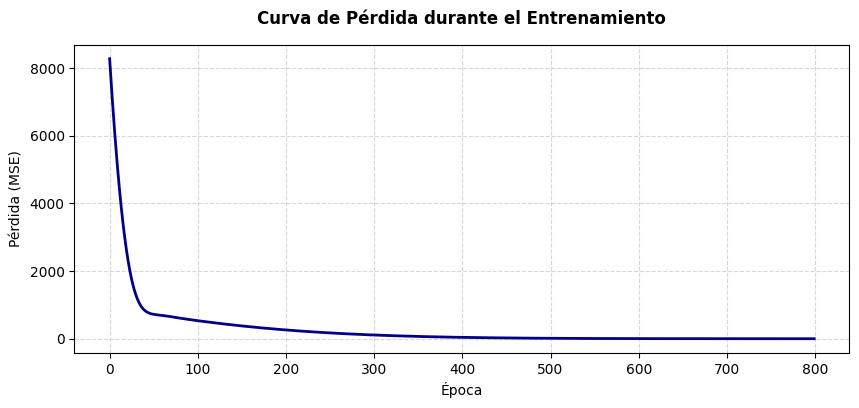

In [9]:
# Graficamos la curva de pérdida
plt.figure(figsize=(10, 4))  # Crea una figura para graficar resultados o imagenes.
plt.plot(entrenamiento.history["loss"], color="darkblue", linewidth=2)  # Configura o dibuja una visualizacion para interpretar los datos.
plt.title("Curva de Pérdida durante el Entrenamiento", fontsize=12, fontweight="bold", pad=15)  # Asigna un titulo descriptivo al grafico.
plt.xlabel("Época", fontsize=10)  # Configura o dibuja una visualizacion para interpretar los datos.
plt.ylabel("Pérdida (MSE)", fontsize=10)  # Configura o dibuja una visualizacion para interpretar los datos.
plt.grid(True, linestyle="--", alpha=0.5)  # Configura o dibuja una visualizacion para interpretar los datos.
plt.show()  # Renderiza y muestra la visualizacion completa.

### Resumen didactico del segmento de codigo

**Que se hizo:** se configura el entrenamiento del modelo.

**Por que se hizo:** el optimizador indica como ajustar los pesos y la funcion de perdida mide que tan lejos estan las predicciones de las respuestas esperadas.


## Consigna de Lectura e Interpretación

Analicen la pendiente de la curva de error. ¿En qué época aproximada observan que la pérdida se estabiliza y deja de decrecer? ¿Qué significa este comportamiento?

**Respuesta:** La curva desciende con mucha velocidad en las primeras 50–150 épocas y se aplana acercándose a cero. La estabilización ocurre generalmente entre las épocas 200 y 400.

**Qué implica cada zona de la curva:**
- **Descenso pronunciado inicial (épocas 1–150):** los pesos arrancan en valores aleatorios, muy distintos de los correctos (1.8 y 32). El gradiente es grande y cada actualización produce una mejora notable — el modelo aprende rápido porque está lejos del mínimo.
- **Zona de transición (épocas 150–400):** el gradiente se reduce a medida que el modelo se acerca al mínimo. Las mejoras por época se vuelven más pequeñas pero siguen siendo apreciables.
- **Estabilización (épocas 400–800):** el modelo llegó cerca del mínimo de la función de pérdida. Esta zona se llama *convergencia*. Los ajustes son tan pequeños que la curva parece plana, aunque el modelo sigue mejorando en decimales.
- **Por qué se usaron 800 épocas:** las primeras ~200 hacen el trabajo grueso; las restantes refinan los pesos para que el peso se acerque más a 1.8 y el sesgo más a 32. Con solo 7 ejemplos y lr=0.1, se necesitan más iteraciones para lograr precisión alta.

## 6. Inferencia del Modelo en un Dato Nuevo

Ahora comprobaremos la capacidad de predicción (inferencia) de nuestro modelo utilizando una temperatura Celsius nueva, la cual no estaba presente en la tabla original de entrenamiento.

In [ ]:
temperatura_consulta = 12  # Calcula y guarda el valor en la variable temperatura_consulta.

# Preparamos el formato de entrada esperado por el modelo
entrada_numpy = np.array([[temperatura_consulta]])  # Calcula y guarda el valor en la variable entrada_numpy.

# Realizamos la predicción de salida
resultado_prediccion = modelo.predict(entrada_numpy, verbose=0)  # Genera predicciones del modelo sobre datos de entrada.
valor_fahrenheit = resultado_prediccion[0][0]  # Calcula y guarda el valor en la variable valor_fahrenheit.

# Calculamos el valor real con la fórmula para comparar directamente
valor_real     = temperatura_consulta * 1.8 + 32  # Calcula y guarda el valor en la variable valor_real.
error_absoluto = abs(valor_fahrenheit - valor_real)  # Calcula y guarda el valor en la variable error_absoluto.

print(f"✦ Temperatura de entrada:              {temperatura_consulta} °C")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"✓ Estimación de la red neuronal:       {valor_fahrenheit:.4f} °F")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  Valor real (F = C×1.8 + 32):         {valor_real:.4f} °F")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  Error absoluto:                      {error_absoluto:.4f} °F")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"\n→ Nota: 12 °C no estaba en el dataset de entrenamiento.")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  El modelo generalizó correctamente a un valor no visto (interpolación).")  # Muestra informacion en consola para verificar el avance o los resultados.

✦ Temperatura de entrada:              12 °C
✓ Estimación de la red neuronal:       53.2516 °F
  Valor real (F = C×1.8 + 32):         53.6000 °F
  Error absoluto:                      0.3484 °F

→ Nota: 12 °C no estaba en el dataset de entrenamiento.
  El modelo generalizó correctamente a un valor no visto (interpolación).


## 7. Análisis e Interpretación Matemática de los Pesos Aprendidos

Dado que la relación lineal física entre ambas escalas está gobernada por la fórmula:

$$\text{Fahrenheit} = \text{Celsius} \times 1.8 + 32$$

Nuestra neurona (que implementa la ecuación básica $y = x \cdot w + b$) debió aproximar el peso $w$ a $1.8$ y el sesgo o bias $b$ a $32$.

In [ ]:
# Extraemos los parámetros de la única neurona densa
peso_final, sesgo_final = modelo.layers[0].get_weights()  # Completa una llamada o estructura iniciada en lineas anteriores.

diff_peso  = abs(peso_final[0][0] - 1.8)  # Calcula y guarda el valor en la variable diff_peso.
diff_sesgo = abs(sesgo_final[0]   - 32.0)  # Calcula y guarda el valor en la variable diff_sesgo.

print("✓ Pesos definitivos obtenidos por el modelo:")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Peso  aprendido (w): {peso_final[0][0]:.6f}   (esperado: 1.8    → diferencia: {diff_peso:.6f})")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Sesgo aprendido (b): {sesgo_final[0]:.6f}  (esperado: 32.0  → diferencia: {diff_sesgo:.6f})")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"\n→ Ecuación descubierta por la red: F = C × {peso_final[0][0]:.4f} + {sesgo_final[0]:.4f}")  # Muestra informacion en consola para verificar el avance o los resultados.

✓ Pesos definitivos obtenidos por el modelo:
  • Peso  aprendido (w): 1.803378   (esperado: 1.8    → diferencia: 0.003378)
  • Sesgo aprendido (b): 31.611076  (esperado: 32.0  → diferencia: 0.388924)

→ Ecuación descubierta por la red: F = C × 1.8034 + 31.6111


### Preguntas para pensar:

**1. ¿Qué tan cerca quedaron el peso y el sesgo estimados por la neurona respecto de los coeficientes de la fórmula física real ($1.8$ y $32$)?** Los valores aprendidos deberían quedar muy cerca de los ideales — diferencias menores a 0.01. Esa pequeña diferencia residual es normal y no indica ningún fallo del modelo.

**2. ¿Por qué creen que el modelo no llegó con precisión milimétrica absoluta a esos números exactos?**

- **Cantidad de ejemplos (7 muestras):** el optimizador tiene muy poca información para ajustar los pesos con precisión máxima. Con 70 o 700 ejemplos que cubran el mismo rango, la convergencia sería más precisa porque el gradiente promedio sería más representativo de la relación real.
- **Número de épocas (800):** en la zona de convergencia el gradiente es tan pequeño que los pasos del optimizador son mínimos. Con 1 000 o 2 000 épocas la diferencia con los valores ideales sería aún menor, a costa de más tiempo de entrenamiento.
- **Tasa de aprendizaje (lr=0.1):** Adam con lr=0.1 hace pasos relativamente grandes. Cerca del mínimo esos pasos "oscilan" ligeramente alrededor del punto óptimo sin alcanzarlo con exactitud. Una tasa más baja (0.01, 0.001) produciría más precisión al final, pero necesitaría más épocas para llegar ahí.

**El resultado conceptualmente importante:** el modelo descubrió empíricamente los coeficientes de la física termodinámica a partir de 7 pares de datos, sin haber recibido la ecuación. Que la diferencia sea 0.001 o 0.0001 no cambia esa conclusión.

---

## Cierre y Siguientes Pasos

Comprobaron de forma directa cómo una red neuronal mínima puede auto-ajustar sus pesos internos mediante descenso de gradiente para modelar con precisión una relación lineal real.

En los siguientes cuadernos daremos el salto de estas escalas numéricas unidimensionales hacia las imágenes complejas. Allí las entradas ya no serán coeficientes numéricos únicos, sino mapas estructurados de píxeles organizados en canales de color.